In [2]:
import pandas as pd
import numpy as np

from sklearn import set_config
set_config(display="text")

import warnings
warnings.filterwarnings('ignore')

# 문제 정의  
##### 서울 지역(구)의 경도와 위도 정보를 사용하여, 임의로 입력된 지역(동)을 강동, 강서, 강남, 강북으로 의사 결정 트리 알고리즘으로 분류해보는 예제.

# 데이터 수집  
#####  서울의 대표적인 구(district) 위치 데이터임. 구(district) 정보는 학습에 사용하도록 하겠음.

In [3]:
# 훈련 데이터 제공

district_dict_list = [
            {'district': 'Gangseo-gu', 'latitude': 37.551000, 'longitude': 126.849500, 'label':'Gangseo'},
            {'district': 'Yangcheon-gu', 'latitude': 37.52424, 'longitude': 126.855396, 'label':'Gangseo'},
            {'district': 'Guro-gu', 'latitude': 37.4954, 'longitude': 126.8874, 'label':'Gangseo'},
            {'district': 'Geumcheon-gu', 'latitude': 37.4519, 'longitude': 126.9020, 'label':'Gangseo'},
            {'district': 'Mapo-gu', 'latitude': 37.560229, 'longitude': 126.908728, 'label':'Gangseo'},
            
            {'district': 'Gwanak-gu', 'latitude': 37.487517, 'longitude': 126.915065, 'label':'Gangnam'},
            {'district': 'Dongjak-gu', 'latitude': 37.5124, 'longitude': 126.9393, 'label':'Gangnam'},
            {'district': 'Seocho-gu', 'latitude': 37.4837, 'longitude': 127.0324, 'label':'Gangnam'},
            {'district': 'Gangnam-gu', 'latitude': 37.5172, 'longitude': 127.0473, 'label':'Gangnam'},
            {'district': 'Songpa-gu', 'latitude': 37.503510, 'longitude': 127.117898, 'label':'Gangnam'},
   
            {'district': 'Yongsan-gu', 'latitude': 37.532561, 'longitude': 127.008605, 'label':'Gangbuk'},
            {'district': 'Jongro-gu', 'latitude': 37.5730, 'longitude': 126.9794, 'label':'Gangbuk'},
            {'district': 'Seongbuk-gu', 'latitude': 37.603979, 'longitude': 127.056344, 'label':'Gangbuk'},
            {'district': 'Nowon-gu', 'latitude': 37.6542, 'longitude': 127.0568, 'label':'Gangbuk'},
            {'district': 'Dobong-gu', 'latitude': 37.6688, 'longitude': 127.0471, 'label':'Gangbuk'},
     
            {'district': 'Seongdong-gu', 'latitude': 37.557340, 'longitude': 127.041667, 'label':'Gangdong'},
            {'district': 'Dongdaemun-gu', 'latitude': 37.575759, 'longitude': 127.025288, 'label':'Gangdong'},
            {'district': 'Gwangjin-gu', 'latitude': 37.557562, 'longitude': 127.083467, 'label':'Gangdong'},
            {'district': 'Gangdong-gu', 'latitude': 37.554194, 'longitude': 127.151405, 'label':'Gangdong'},
            {'district': 'Jungrang-gu', 'latitude': 37.593684, 'longitude': 127.090384, 'label':'Gangdong'}
         ]

train_df = pd.DataFrame(district_dict_list)
train_df = train_df[['district', 'longitude', 'latitude', 'label']]  # List 자료형
train_df


,district,longitude,latitude,label
0,Gangseo-gu,126.849500,37.551000,Gangseo
1,Yangcheon-gu,126.855396,37.524240,Gangseo
2,Guro-gu,126.887400,37.495400,Gangseo
3,Geumcheon-gu,126.902000,37.451900,Gangseo
4,Mapo-gu,126.908728,37.560229,Gangseo
5,Gwanak-gu,126.915065,37.487517,Gangnam
6,Dongjak-gu,126.939300,37.512400,Gangnam
7,Seocho-gu,127.032400,37.483700,Gangnam
8,Gangnam-gu,127.047300,37.517200,Gangnam
9,Songpa-gu,127.117898,37.503510,Gangnam


In [4]:
dong_dict_list = [
            {'dong': 'Gaebong-dong', 'latitude': 37.489853, 'longitude': 126.854547, 'label':'Gangseo'},
            {'dong': 'Gochuk-dong', 'latitude': 37.501394, 'longitude': 126.859245, 'label':'Gangseo'},
            {'dong': 'Hwagok-dong', 'latitude': 37.537759, 'longitude': 126.847951, 'label':'Gangseo'},
            {'dong': 'Banghwa-dong', 'latitude': 37.575817, 'longitude': 126.815719, 'label':'Gangseo'},
            {'dong': 'Sangam-dong', 'latitude': 37.577039, 'longitude': 126.891620, 'label':'Gangseo'},
            
            {'dong': 'Nonhyun-dong', 'latitude': 37.508838, 'longitude': 127.030720, 'label':'Gangnam'},
            {'dong': 'Daechi-dong', 'latitude': 37.501163, 'longitude': 127.057193, 'label':'Gangnam'},
            {'dong': 'Seocho-dong', 'latitude': 37.486401, 'longitude': 127.018281, 'label':'Gangnam'},
            {'dong': 'Bangbae-dong', 'latitude': 37.483279, 'longitude': 126.988194, 'label':'Gangnam'},
            {'dong': 'Dogok-dong', 'latitude': 37.492896, 'longitude': 127.043159, 'label':'Gangnam'},
    
            {'dong': 'Pyoungchang-dong', 'latitude': 37.612129, 'longitude': 126.975724, 'label':'Gangbuk'},
            {'dong': 'Sungbuk-dong', 'latitude': 37.597916, 'longitude': 126.998067, 'label':'Gangbuk'},
            {'dong': 'Ssangmoon-dong', 'latitude': 37.648094, 'longitude': 127.030421, 'label':'Gangbuk'},
            {'dong': 'Ui-dong', 'latitude': 37.648446, 'longitude': 127.011396, 'label':'Gangbuk'},
            {'dong': 'Samcheong-dong', 'latitude': 37.591109, 'longitude': 126.980488, 'label':'Gangbuk'},
    
            {'dong': 'Hwayang-dong', 'latitude': 37.544234, 'longitude': 127.071648, 'label':'Gangdong'},
            {'dong': 'Gui-dong', 'latitude': 37.543757, 'longitude': 127.086803, 'label':'Gangdong'},
            {'dong': 'Neung-dong', 'latitude': 37.553102, 'longitude': 127.080248, 'label':'Gangdong'},
            {'dong': 'Amsa-dong', 'latitude': 37.552370, 'longitude': 127.127124, 'label':'Gangdong'},
            {'dong': 'Chunho-dong', 'latitude': 37.547436, 'longitude': 127.137382, 'label':'Gangdong'}
         ]

test_df = pd.DataFrame(dong_dict_list)
test_df = test_df[['dong', 'longitude', 'latitude', 'label']]  # longitude(위도), latitude(경도)
test_df

,dong,longitude,latitude,label
0,Gaebong-dong,126.854547,37.489853,Gangseo
1,Gochuk-dong,126.859245,37.501394,Gangseo
2,Hwagok-dong,126.847951,37.537759,Gangseo
3,Banghwa-dong,126.815719,37.575817,Gangseo
4,Sangam-dong,126.891620,37.577039,Gangseo
5,Nonhyun-dong,127.030720,37.508838,Gangnam
6,Daechi-dong,127.057193,37.501163,Gangnam
7,Seocho-dong,127.018281,37.486401,Gangnam
8,Bangbae-dong,126.988194,37.483279,Gangnam
9,Dogok-dong,127.043159,37.492896,Gangnam


In [5]:
# 현재 가지고 있는 데이터에서, 레이블 갯수를 확인
train_df.label.value_counts()

label
Gangseo     5
Gangnam     5
Gangbuk     5
Gangdong    5
Name: count, dtype: int64

In [6]:
test_df.label.value_counts()

label
Gangseo     5
Gangnam     5
Gangbuk     5
Gangdong    5
Name: count, dtype: int64

# 데이터 전처리
##### 먼저, 경도와 위도의 평균과 편차를 보도록 하겠음.

In [7]:
train_df.describe()

,longitude,latitude
count,20.000000,20.000000
mean,126.999772,37.547909
std,0.089387,0.055086
min,126.849500,37.451900
25%,126.913481,37.510177
50%,127.028844,37.552597
75%,127.056458,37.573690
max,127.151405,37.668800


# 데이터 시각화

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'district visualization in 2d plane')

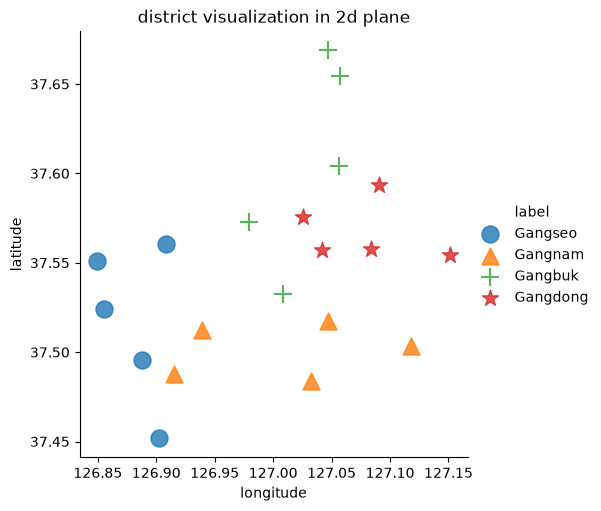

In [9]:
sns.lmplot(x='longitude', y='latitude', data=train_df, fit_reg=False,
           scatter_kws={'s':150},
           markers=['o', '^', '+', '*'],
           hue='label')

plt.title('district visualization in 2d plane')

# 데이터 다듬기
##### 학습 및 테스트에 필요없는 특징(feature)의 데이터 제거. 구 이름 및 동 이름은 학습 및 테스트에 필요 없으므로, 제거.

In [10]:
train_df.drop(['district'] , axis=1, inplace=True)
test_df.drop(['dong'], axis=1, inplace=True)   
print(train_df.head())
print(test_df.head())

    longitude   latitude    label
0  126.849500  37.551000  Gangseo
1  126.855396  37.524240  Gangseo
2  126.887400  37.495400  Gangseo
3  126.902000  37.451900  Gangseo
4  126.908728  37.560229  Gangseo
    longitude   latitude    label
0  126.854547  37.489853  Gangseo
1  126.859245  37.501394  Gangseo
2  126.847951  37.537759  Gangseo
3  126.815719  37.575817  Gangseo
4  126.891620  37.577039  Gangseo


In [11]:
# 훈련 데이터
X_train = train_df[['longitude', 'latitude']]
y_train = train_df[['label']]

In [12]:
# 테스트 데이터
X_test = test_df[['longitude', 'latitude']]  # dong 데이터
y_test = test_df[['label']]


# 모델 생성

In [13]:
from sklearn import tree
from sklearn import preprocessing

In [14]:
# 의사결정 트리 : 데이터 분류 및 회귀에 둘다 사용

clf = tree.DecisionTreeClassifier(random_state=35)   # 분류용 모델 생성

In [15]:
# pyplot은 숫자로 표현된 레이블을 시각화할 수 있음.
# LabelEncoder로 레이블을 숫자로 변경.

le = preprocessing.LabelEncoder() 
y_encoded = le.fit_transform(y_train) # 입력으로 전달된 텍스트 데이터를 숫자형으로 변환
print(y_encoded)


[3 3 3 3 3 2 2 2 2 2 0 0 0 0 0 1 1 1 1 1]


In [16]:
clf = tree.DecisionTreeClassifier(random_state=35)   # 분류용 모델 생성
clf.fit(X_train, y_encoded) # 훈련 데이터, 정답 데이터를 파라미터로 학습시킨다
# clf 최적화된 예측 모델이 만들어 짐

DecisionTreeClassifier(random_state=35)

In [17]:
def display_decision_surface(clf, X, y):   # 모델, 훈련 데이터, 정답 데이터 파라미터

    # 배경화면
    # 차트의 범위가 모든 학습 데이터를 포함하도록 설정
    x_min = X.longitude.min() - 0.01
    x_max = X.longitude.max() + 0.01
    y_min = X.latitude.min() - 0.01
    y_max = X.latitude.max() + 0.01
    
    # 파라미터 설정
    n_classes = len(le.classes_)
    plot_colors = "rywb"
    plot_step = 0.001
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), # 시작, 끝, 스텝
                         np.arange(y_min, y_max, plot_step))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])  # predict ravel 2차원의 값을 1차원으로 펼친다
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)  # contourf 시각화 
    
    # 학습 데이터를 차트에 표시
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X.loc[idx].longitude,
                    X.loc[idx].latitude,
                    c=color,
                    label=le.classes_[i],
                    cmap=plt.cm.RdYlBu, 
                    edgecolor='black', s=200)
        
    # 차트 제목
    plt.title('Decision surface of a desicsion tree', fontsize=16)
    # 범례
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc='lower left', fontsize=14)
    # x축의 이름과 폰트 크기 설정
    plt.xlabel('longitude', fontsize=16)
    # y축의 이름과 폰트 크기 설정
    plt.ylabel('latitude', fontsize=16)
    # 차트 크기 설정
    plt.rcParams['figure.figsize'] = [7, 5]
    # x축 좌표상의 폰트 크기 설정
    plt.rcParams['xtick.labelsize'] = 14
    # y축 좌표상의 폰트 크기 설정
    plt.rcParams['ytick.labelsize'] = 14
    
    # 차트 그리기
    plt.show()

## 파라미터 없이 학습한 모델의 결정 표면 시각화

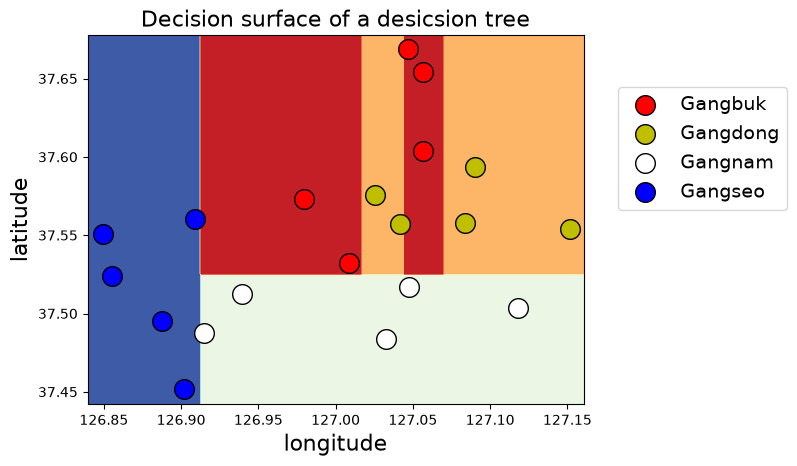

In [18]:
display_decision_surface(clf, X_train, y_encoded)


## 파라미터 설정한 모델의 결정 표면 시각화

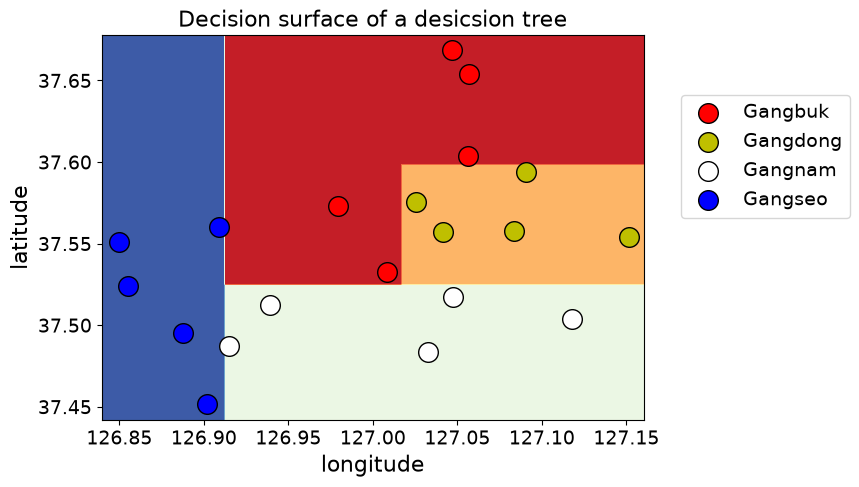

In [19]:
# Hyper 파라미터 설정(튜닝)
# max_depth(깊을수록 훈련 데이터에 최적화 됨), min_samples_split ,,,,

clf = tree.DecisionTreeClassifier(max_depth=4, # 트리의 최대 한도 깊이
                            min_samples_split=2, # 자식 노드를 갖기 위한 최소한의 데이터 갯수
                            min_samples_leaf=2, # 맨 마지막 끝 노드의 최소 데이터 갯수
                            random_state=70 # 여러번 실행해도, 파라미터가 같은 경우, 결과가 항상 같게 만들어주는 파라미터
                           )

clf.fit(X_train, y_encoded)
display_decision_surface(clf, X_train, y_encoded)


## 의사결정트리 시각화

In [20]:
# https://graphviz.org/download/
# !pip install graphviz pydotplus   # 설치 완료되고 난 후 VS Code 재시작

In [21]:
import os
import sys
from graphviz import Digraph

# Graphviz가 설치된 실제 bin 경로를 PATH에 임시로 추가합니다.
# (기본 설치 경로 기준이며, 설치 위치가 다르다면 해당 경로로 수정하세요)
graphviz_bin_path = r"C:\Program Files\Graphviz\bin"

if graphviz_bin_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.path.pathsep + graphviz_bin_path

# --- Graphviz 실행 예시 ---
def main():
    # 간단한 유방향 그래프(Digraph) 생성
    dot = Digraph(comment='System Architecture Test')
    
    # 노드 추가
    dot.node('A', 'Input Data')
    dot.node('B', 'Model Processing')
    dot.node('C', 'Output Result')
    
    # 간선(연결) 추가
    dot.edges(['AB', 'BC'])
    
    # 그래프 시각화 및 파일 저장 (test_output.gv.pdf 생성)
    output_filename = dot.render('test_output.gv', view=False)
    print(f"Graph successfully generated at: {output_filename}")

if __name__ == "__main__":
    main()

Graph successfully generated at: test_output.gv.pdf


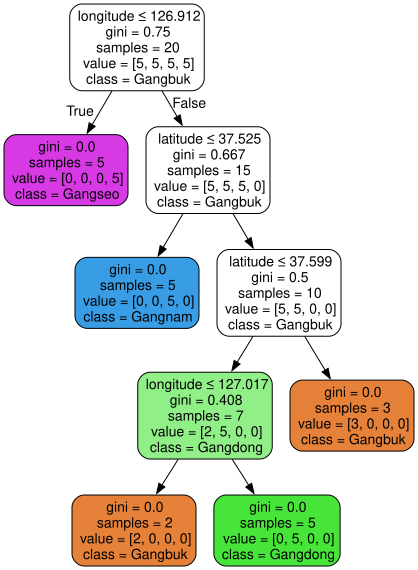

In [22]:
import graphviz

dot_data = tree.export_graphviz(clf)
graph = graphviz.Source(dot_data)
graph.render('seoul')

dot_data = tree.export_graphviz(clf, out_file=None, 
                    feature_names=['longitude', 'latitude'],
                    class_names=['Gangbuk', 'Gangdong', 'Gangnam', 'Gangseo'],
                    filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph

# 테스트(성능 평가)

In [27]:
# 학습에서 한번도 사용하지 않은 데이터를 사용해야 신뢰도 향상

from sklearn.metrics import accuracy_score  # metrics : 분류알고리즘(혼동행렬)

pred = clf.predict(X_test) # 모델에게 예측해라고 명령


In [28]:
# 정답과 예측값을 비교

comparison = pd.DataFrame({'예측값': le.classes_[pred], '정답':y_test.values.ravel()})
comparison

,예측값,정답
0,Gangseo,Gangseo
1,Gangseo,Gangseo
2,Gangseo,Gangseo
3,Gangseo,Gangseo
4,Gangseo,Gangseo
5,Gangnam,Gangnam
6,Gangnam,Gangnam
7,Gangnam,Gangnam
8,Gangnam,Gangnam
9,Gangnam,Gangnam


In [ ]:
print('accuracy: ' + str(accuracy_score(y_test.values.ravel(), le.classes_[pred])))

# accuracy: 1.0 -> 100 % 예측률을 보임

accuracy: 1.0
